<h2>Quick Start: Creating Sample-wise Unlearnable Examples For Sound</h2>

<h3> Preparation </h3>

图像张量形状: torch.Size([512, 3, 32, 32])
标签分布: tensor([80, 80, 80, 80, 80, 79, 33])


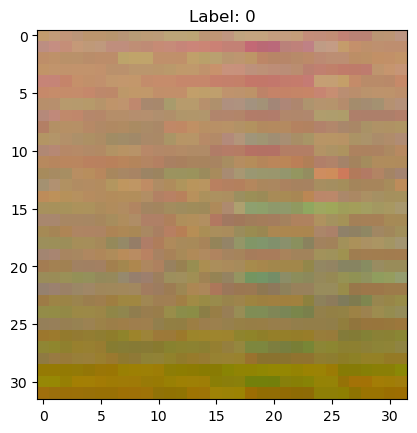

In [2]:
import librosa
import numpy as np
from PIL import Image
import os
import sys
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

# Locate repository root so the notebook works from VSCode, Jupyter, or shell execution.
repo_root = Path.cwd().resolve()
while not (repo_root / "ml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

GTZAN_AUDIO_CANDIDATES = [
    Path("data/datasets/gtzan/raw/genres_original"),
    Path("data/raw/GTZAN/GTZAN/genres_original"),
]
GTZAN_AUDIO_DIR = next((p for p in GTZAN_AUDIO_CANDIDATES if p.exists()), None)
if GTZAN_AUDIO_DIR is None:
    raise FileNotFoundError("GTZAN genres_original directory not found")

SPECTROGRAM_ALL_DIR = Path("data/processed/spectrograms/all")
SPECTROGRAM_TRAIN_DIR = Path("data/processed/spectrograms/train")
SPECTROGRAM_TEST_DIR = Path("data/processed/spectrograms/test")
CIFAR_BIN_DIR = Path("data/processed/cifar_bin")
NUM_WORKERS = min(4, os.cpu_count() or 1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def generate_spectrogram(audio_path, output_dir, target_size=(32,32)):
    # 加载音频
    audio_path = Path(audio_path)
    output_dir = Path(output_dir)
    class_name = audio_path.parent.name
    output_file = output_dir / class_name / f"{audio_path.stem}.png"
    if output_file.exists():
        return True
    try:
        y, sr = librosa.load(audio_path, duration=30)  # GTZAN每段音频30秒
    except Exception as exc:
        print(f"跳过无法读取音频: {audio_path} ({exc.__class__.__name__})")
        return False
    
    # 生成Mel频谱图
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # 归一化到0-255
    norm_S = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min()) * 255
    img = Image.fromarray(norm_S).convert("L")  # 先转为灰度
    
    # 调整尺寸并转为RGB
    img = img.resize(target_size).convert("RGB")
    
    # 保存图像（文件名保留类别信息）
    output_file.parent.mkdir(parents=True, exist_ok=True)
    img.save(output_file)
    return True

def process_all_audio(input_dir, output_dir):
    for class_name in os.listdir(input_dir):
        class_dir = os.path.join(input_dir, class_name)
        if os.path.isdir(class_dir):
            for audio_file in os.listdir(class_dir):
                if audio_file.endswith(".wav"):
                    generate_spectrogram(
                        os.path.join(class_dir, audio_file),
                        output_dir
                    )
                    
def convert_gtzan_to_cifar(spectrogram_dir, output_path):
    label_map = {
        "blues": 0,
        "classical": 1,
        "country": 2,
        "disco": 3,
        "hiphop": 4,
        "jazz": 5,
        "metal": 6,
        "pop": 7,
        "reggae": 8,
        "rock": 9
    }
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with open(output_path, "wb") as f:
        for class_name, label in label_map.items():
            class_dir = os.path.join(spectrogram_dir, class_name)
            images = [f for f in os.listdir(class_dir) if f.endswith(".png")]
            
            for img_file in images:
                img_path = os.path.join(class_dir, img_file)
                with Image.open(img_path) as img:
                    arr = np.array(img).astype(np.uint8)
                
                # 验证尺寸
                if arr.shape != (32,32,3):
                    raise ValueError(f"Invalid shape: {arr.shape} in {img_path}")
                
                # 打包数据：1字节标签 + 3072字节图像数据
                f.write(bytes([label]))
                f.write(arr.tobytes())
                


# Step 1: 生成频谱图
process_all_audio(GTZAN_AUDIO_DIR, SPECTROGRAM_ALL_DIR)

# Step 2: 划分训练测试集（GTZAN每个类别100个样本，按80:20划分）
from sklearn.model_selection import train_test_split
import shutil

# Rebuild the split directories on each run so repeated notebook execution does not accumulate samples.
for split_dir in [SPECTROGRAM_TRAIN_DIR, SPECTROGRAM_TEST_DIR]:
    if split_dir.exists():
        shutil.rmtree(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)

for class_name in os.listdir(SPECTROGRAM_ALL_DIR):
    all_images = [os.path.join(SPECTROGRAM_ALL_DIR, class_name, f) 
                 for f in os.listdir(os.path.join(SPECTROGRAM_ALL_DIR, class_name))]
    train, test = train_test_split(all_images, test_size=0.2, random_state=42)
    
    # 创建训练集目录
    os.makedirs(os.path.join(SPECTROGRAM_TRAIN_DIR, class_name), exist_ok=True)
    os.makedirs(os.path.join(SPECTROGRAM_TEST_DIR, class_name), exist_ok=True)
    
    # 复制文件
    for f in train:
        shutil.copy(f, os.path.join(SPECTROGRAM_TRAIN_DIR, class_name))
    for f in test:
        shutil.copy(f, os.path.join(SPECTROGRAM_TEST_DIR, class_name))

# Step 3: 生成二进制文件
convert_gtzan_to_cifar(SPECTROGRAM_TRAIN_DIR, CIFAR_BIN_DIR / "train.bin")
convert_gtzan_to_cifar(SPECTROGRAM_TEST_DIR, CIFAR_BIN_DIR / "test.bin")


from torch.utils.data import Dataset, DataLoader

class GtzanCIFAR10(Dataset):
    def __init__(self, root, train=True, transform=None,target_transform=None):
        """
        Args:
            root (str): 二进制文件路径目录(如包含train.bin和test.bin的目录)
            train (bool): 是否为训练集
            transform (callable): 数据增强/预处理
        """
        self.transform = transform
        self.target_transform = target_transform
        filename = "train.bin" if train else "test.bin"
        filepath = os.path.join(root, filename)
        
        # 一次性加载所有数据到内存
        with open(filepath, "rb") as f:
            data = f.read()
        
        # 解析二进制数据
        self.data = []
        self.targets = []
        for i in range(0, len(data), 3073):
            label = data[i]
            img_data = np.frombuffer(data[i+1:i+3073], dtype=np.uint8)
            img = img_data.reshape(3, 32, 32).transpose(1, 2, 0)  # 转换为HWC格式
            self.data.append(img)
            self.targets.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        target = self.targets[idx]
        img = Image.fromarray(img)
        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target

# 修改后的数据准备代码
train_transform = transforms.Compose([
    transforms.ToTensor()
    # 自动将numpy数组转为Tensor并归一化到[0,1]
    # 如果需要可以添加CIFAR-10的标准归一化：
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# 创建自定义数据集实例
clean_train_dataset = GtzanCIFAR10(
    root=CIFAR_BIN_DIR,  # 指向你的二进制文件目录
    train=True,
    transform=train_transform
)

clean_test_dataset = GtzanCIFAR10(
    root=CIFAR_BIN_DIR,
    train=False,
    transform=test_transform
)

# 保持原有DataLoader配置不变
clean_train_loader = DataLoader(
    dataset=clean_train_dataset,
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    drop_last=False,
    num_workers=NUM_WORKERS
)

clean_test_loader = DataLoader(
    dataset=clean_test_dataset,
    batch_size=512,
    shuffle=False,
    pin_memory=True,
    drop_last=False,
    num_workers=NUM_WORKERS
)
# 测试第一个batch
sample_images, sample_labels = next(iter(clean_train_loader))
print(f"图像张量形状: {sample_images.shape}")  # 应显示 torch.Size([512, 3, 32, 32])
print(f"标签分布: {torch.bincount(sample_labels)}")  # 应显示各类别数量

# 可视化示例图像
import matplotlib.pyplot as plt
img = sample_images[0].permute(1, 2, 0).numpy()  # CHW -> HWC
plt.imshow(img)
plt.title(f"Label: {sample_labels[0].item()}")
plt.show()


<h3> Prepare Model</h3>

In [3]:
from ml.models.ResNet import ResNet18
from ml import toolbox

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

base_model = ResNet18().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=base_model.parameters(), lr=0.1, weight_decay=0.0005, momentum=0.9)

noise_generator = toolbox.PerturbationTool(epsilon=0.03137254901960784, num_steps=20, step_size=0.0031372549019607846)


<h3>Generate Error-Minimizing Noise</h3>

In [9]:
from tqdm import tqdm

noise = torch.zeros([len(clean_train_dataset), 3, 32, 32])
data_iter = iter(clean_train_loader)
condition = True
train_idx = 0

while condition:
    # optimize theta for M steps
    base_model.train()
    for param in base_model.parameters():
        param.requires_grad = True
    for j in range(0, 10):
        try:
            (images, labels) = next(data_iter)
        except:
            train_idx = 0
            data_iter = iter(clean_train_loader)
            (images, labels) = next(data_iter)
        
        for i, _ in enumerate(images):
            # Update noise to images
            images[i] += noise[train_idx]
            train_idx += 1
        images, labels = images.to(device), labels.to(device)
        base_model.zero_grad()
        optimizer.zero_grad()
        logits = base_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), 5.0)
        optimizer.step()
    
    # Perturbation over entire dataset
    idx = 0
    for param in base_model.parameters():
        param.requires_grad = False
    for i, (images, labels) in tqdm(enumerate(clean_train_loader), total=len(clean_train_loader)):
        batch_start_idx, batch_noise = idx, []
        for i, _ in enumerate(images):
            # Update noise to images
            batch_noise.append(noise[idx])
            idx += 1
        batch_noise = torch.stack(batch_noise).to(device)
        
        # Update sample-wise perturbation
        base_model.eval()
        images, labels = images.to(device), labels.to(device)
        perturb_img, eta = noise_generator.min_min_attack(images, labels, base_model, optimizer, criterion, 
                                                          random_noise=batch_noise)
        for i, delta in enumerate(eta):
            noise[batch_start_idx+i] = delta.clone().detach().cpu()
        
    # Eval stop condition
    eval_idx, total, correct = 0, 0, 0
    for i, (images, labels) in enumerate(clean_train_loader):
        for i, _ in enumerate(images):
            # Update noise to images
            images[i] += noise[eval_idx]
            eval_idx += 1
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = base_model(images)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    print('Accuracy %.2f' % (acc*100))
    if acc > 0.99:
        condition=False


100%|██████████| 2/2 [00:06<00:00,  3.28s/it]


Accuracy 51.44


100%|██████████| 2/2 [00:06<00:00,  3.32s/it]


Accuracy 91.74


100%|██████████| 2/2 [00:06<00:00,  3.44s/it]


Accuracy 96.75


100%|██████████| 2/2 [00:06<00:00,  3.46s/it]


Accuracy 95.99


100%|██████████| 2/2 [00:07<00:00,  3.75s/it]


Accuracy 99.87


In [10]:
print(noise)

tensor([[[[-3.1373e-02, -3.1373e-02, -3.1373e-02,  ..., -2.8235e-02,
           -2.8235e-02, -2.8235e-02],
          [ 6.2747e-03,  3.1373e-02,  1.2549e-02,  ..., -2.8235e-02,
           -2.5098e-02, -1.2549e-02],
          [ 3.1373e-02,  3.1373e-02,  3.1373e-02,  ..., -1.8824e-02,
           -3.1373e-02,  6.2742e-03],
          ...,
          [-3.1373e-02, -3.1373e-02, -3.1373e-02,  ..., -3.1373e-02,
           -3.1373e-02, -3.1373e-02],
          [-3.1373e-02, -3.1373e-02, -3.1373e-02,  ..., -3.1373e-02,
           -3.1373e-02, -3.1373e-02],
          [-3.1373e-02, -3.1373e-02, -3.1373e-02,  ..., -3.1373e-02,
           -3.1373e-02, -3.1373e-02]],

         [[-3.1373e-02, -3.1373e-02, -3.1373e-02,  ..., -3.1373e-02,
            1.8824e-02, -2.3842e-07],
          [-3.1373e-02, -3.1373e-02, -3.1373e-02,  ...,  1.2549e-02,
            6.2747e-03, -6.2742e-03],
          [-3.1373e-02, -3.1373e-02, -3.1373e-02,  ...,  6.2747e-03,
            2.5098e-02, -1.8823e-02],
          ...,
     

<h3> Create Unlearnable Dataset </h3>

In [11]:
import numpy as np

# Add standard augmentation
train_transform = [
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
]
train_transform = transforms.Compose(train_transform)
# clean_train_dataset = datasets.CIFAR10(root='../datasets', train=True, download=True, transform=train_transform)
# unlearnable_train_dataset = datasets.CIFAR10(root='../datasets', train=True, download=True, transform=train_transform)

# 创建自定义数据集实例
clean_train_dataset = GtzanCIFAR10(
    root=CIFAR_BIN_DIR,  # 指向你的二进制文件目录
    train=True,
    transform=train_transform
)

unlearnable_train_dataset = GtzanCIFAR10(
    root=CIFAR_BIN_DIR,  # 指向你的二进制文件目录
    train=True,
    transform=train_transform
)


perturb_noise = noise.mul(255).clamp_(0, 255).permute(0, 2, 3, 1).to('cpu').numpy()
unlearnable_train_dataset.data = np.array(unlearnable_train_dataset.data).astype(np.float32)
for i in range(len(unlearnable_train_dataset)):
    unlearnable_train_dataset.data[i] += perturb_noise[i]
    unlearnable_train_dataset.data[i] = np.clip(unlearnable_train_dataset.data[i], a_min=0, a_max=255)
unlearnable_train_dataset.data = np.array(unlearnable_train_dataset.data).astype(np.uint8)


<h3> Visualize </h3>

/home/snoz/anaconda3/envs/robust/lib/python3.8/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


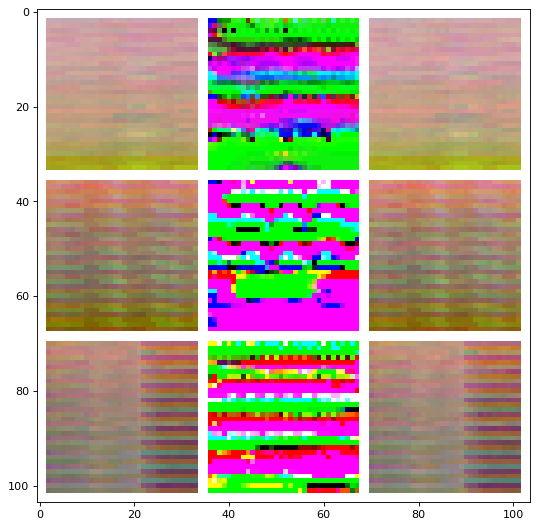

In [13]:
import random
import matplotlib.pyplot as plt
import torchvision
import matplotlib
%matplotlib inline

def imshow(img):
    fig = plt.figure(figsize=(8, 8), dpi=80, facecolor='w', edgecolor='k')
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    
def get_pairs_of_imgs(idx):
    clean_img = clean_train_dataset.data[idx]
    unlearnable_img = unlearnable_train_dataset.data[idx]
    clean_img = torchvision.transforms.functional.to_tensor(clean_img)
    unlearnable_img = torchvision.transforms.functional.to_tensor(unlearnable_img)

    x = noise[idx]
    x_min = torch.min(x)
    x_max = torch.max(x)
    noise_norm = (x - x_min) / (x_max - x_min)
    noise_norm = torch.clamp(noise_norm, 0, 1)
    return [clean_img, noise_norm, unlearnable_img]
    
selected_idx = [random.randint(0, len(clean_train_dataset) - 1) for _ in range(3)]
img_grid = []
for idx in selected_idx:
    img_grid += get_pairs_of_imgs(idx)
    

imshow(torchvision.utils.make_grid(torch.stack(img_grid), nrow=3, pad_value=255))


<h3>Train ResNet18 on Unlearnable Dataset</h3>

In [14]:
from ml.util import AverageMeter

model = ResNet18().to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1, weight_decay=0.0005, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=0)

unlearnable_loader = DataLoader(dataset=unlearnable_train_dataset, batch_size=128,
                                shuffle=True, pin_memory=True,
                                drop_last=False, num_workers=NUM_WORKERS)


for epoch in range(200):
    # Train
    model.train()
    acc_meter = AverageMeter()
    loss_meter = AverageMeter()
    pbar = tqdm(unlearnable_loader, total=len(unlearnable_loader))
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        model.zero_grad()
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        _, predicted = torch.max(logits.data, 1)
        acc = (predicted == labels).sum().item()/labels.size(0)
        acc_meter.update(acc)
        loss_meter.update(loss.item())
        pbar.set_description("Acc %.2f Loss: %.2f" % (acc_meter.avg*100, loss_meter.avg))
    scheduler.step()
    # Eval
    model.eval()
    correct, total = 0, 0
    for i, (images, labels) in enumerate(clean_test_loader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            logits = model(images)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    tqdm.write('Clean Accuracy %.2f\n' % (acc*100))


Acc 18.63 Loss: 2.55: 100%|██████████| 7/7 [00:02<00:00,  2.56it/s]


Clean Accuracy 13.00



Acc 22.69 Loss: 3.46: 100%|██████████| 7/7 [00:00<00:00,  9.36it/s]


Clean Accuracy 10.00



Acc 29.80 Loss: 2.25: 100%|██████████| 7/7 [00:00<00:00,  9.00it/s]


...

Clean Accuracy 28.00



Acc 98.76 Loss: 0.04: 100%|██████████| 7/7 [00:00<00:00,  7.20it/s]


Clean Accuracy 30.50



Acc 98.65 Loss: 0.03: 100%|██████████| 7/7 [00:00<00:00,  8.38it/s] 


Clean Accuracy 30.00

